<a href="https://colab.research.google.com/github/Vishakha133/Credit_Card_Financial_Dashboard/blob/main/Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
conn = sqlite3.connect('/content/customer_churn.db')

#SQL query always write in three codes.

sql_query = """
SELECT name
FROM sqlite_master
WHERE type ='table';
"""

tables = pd.read_sql(sql_query, conn)


#create dataframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df

    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
conn = sqlite3.connect("customer_churn.db")

sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql(sql_query, conn)

print(tables)

conn.close()

              name
0      db_customer
1  db_subscription
2       db_support


In [4]:
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name : {table_name}")
    columns_query = f"PRAGMA table_info({table_name})"
    columns_df = pd.read_sql(columns_query, conn)
    print("columns:")
    print(columns_df['name'].tolist())

conn.close()


Table Name : db_customer
columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name : db_subscription
columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name : db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
#Data Cleaning

In [6]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [7]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [8]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [9]:
#rename column
#drop columns (interest and pincode)
#change data type-dob
#data standardization-gender
#fix missing values- country


In [10]:
#rename column

df_db_customer.rename(columns={'name':'customer_name'}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [11]:
#drop columns (interest and pincode)

df_db_customer = df_db_customer.drop(columns=['interests', 'pincode'])

In [12]:
#change data type-dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [13]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [14]:
#data standardization-gender

#df_db_customer['gender'].unique()
df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [15]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [16]:
#fix missing values- country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [17]:
#country and state unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [18]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [19]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [20]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [21]:
#dot apply  method

date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [22]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [23]:
df_db_support.drop(columns=['col_1','comment'], inplace=True)

In [24]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [25]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [26]:
#Feature Engineering and Data Analysis

In [27]:
#create a new col using existing col - churn_flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [ ]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [28]:
#first fix support table duplicates then merge
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left'))

In [29]:
df_db_subscription.shape

(21, 12)

In [30]:
df.shape

(23, 20)

In [31]:
df_db_subscription['customerid'].nunique()

21

In [32]:
df_db_customer['customerid'].nunique()

21

In [33]:
df_db_support['customerid'].nunique()

7

In [34]:
df_db_support['customerid'].size

9

In [35]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [36]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [37]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [38]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep ='last')

In [43]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [39]:
df_db_support['customerid'].size

7

In [40]:
#merge df
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left'))

In [41]:
df.shape

(21, 21)

In [44]:
df.to_csv('exported_churn_data.csv', index=False)

In [ ]:
from google.colab import files

files.download('exported_churn_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
#Data Analysis

In [47]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [48]:
# Churn Rate
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [49]:
# Retenion Rate
retenion_rate = 100 - churn_rate
print("Retenion Rate = ", round(retenion_rate,2), "%")

Retenion Rate =  71.43 %


In [50]:
# Churn by Plan type
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [52]:
# ARPU- Avg Revenue Per User
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [110]:
import numpy as np
#Total Revenue
# Assuming 'monthly_charges' is the column representing monthly revenue for each customer.
# We will sum this column to get the total monthly revenue across all customers.

total_revenue = df['monthly_charges'].sum()

print(f"Total Revenue (sum of monthly charges) = {total_revenue:.2f}")

Total Revenue (sum of monthly charges) = 395.79


In [114]:
# Avg Customer Tenure
#count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

# Convert relevant columns to datetime objects in df
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'], errors='coerce')
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'], errors='coerce')

df['tenure_days'] = np.where(
     df['cancellation_date'].notna(),
   (df['cancellation_date'] - df['subscription_start_date']).dt.days,
   (today - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure))

Avg Tenure (Days) =  1547


In [55]:
# Revenue at risk - revenue last from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk(Rs 'K')= ",revenue_at_risk)

Revenue at Risk(Rs 'K')=  73.94


In [56]:
# Escalation Rate
escalation_rate = (df['escalations'] =='Y').mean()*100
print('Escalation Rate = ', round(escalation_rate,2), "%")

Escalation Rate =  19.05 %


In [116]:
#CLTV LOST
cltv_lost = df.loc[df['churn_flag'] == 1, 'cltv'].sum()

print("CLTV Lost:", cltv_lost)

CLTV Lost: 2047


In [57]:
# Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User = ", round(avg_complaints,2))

Avg Complaints Per User =  0.43


In [107]:
corr_csat_churn = df[['csat_score', 'churn_flag']].dropna()
correlation_csat_churn = corr_csat_churn['csat_score'].corr(corr_csat_churn['churn_flag'])

print(f"Correlation CSAT Score vs Churn Flag is = {correlation_csat_churn:.2f}")

Correlation CSAT Score vs Churn Flag is = -0.63


In [59]:
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

print("Correlation Escalation vs Churn is =", round(correlation, 2))

Correlation Escalation vs Churn is = 0.77


In [60]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2020.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1405.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2695.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0


In [61]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [62]:
# create a cloumn using existing col - churn risk
conditions = [
           (df['churn_score'] < 50),
           (df['churn_score'] >= 50) & (df['churn_score'] < 70),
           (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions,choices, default ='unkown')

In [ ]:
#Visualization using Matplotlib

In [63]:
df_visual = df.copy()

In [64]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

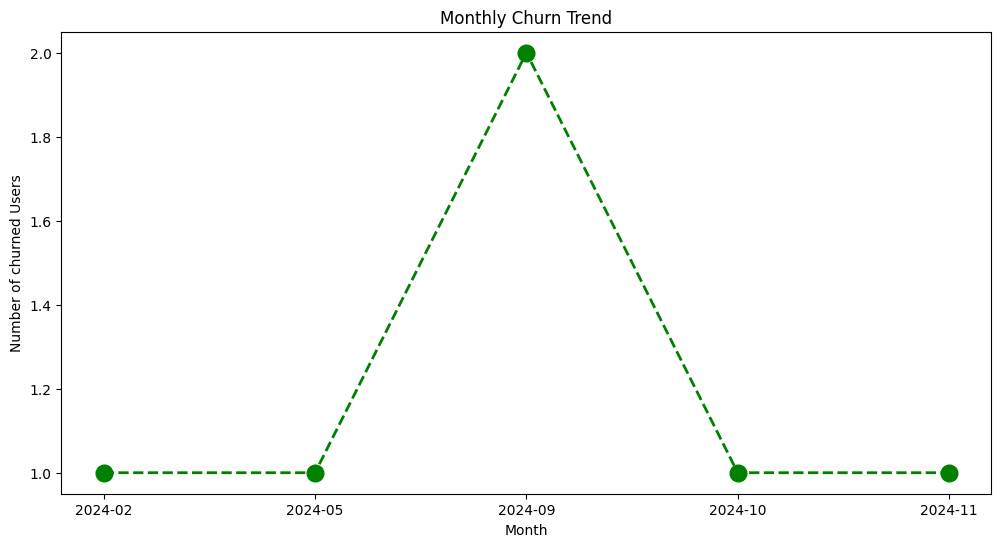

In [65]:
# Monthly churn trend(time series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(12,6))
plt.plot(churn_trend.index.astype('str'), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Number of churned Users')
plt.show()

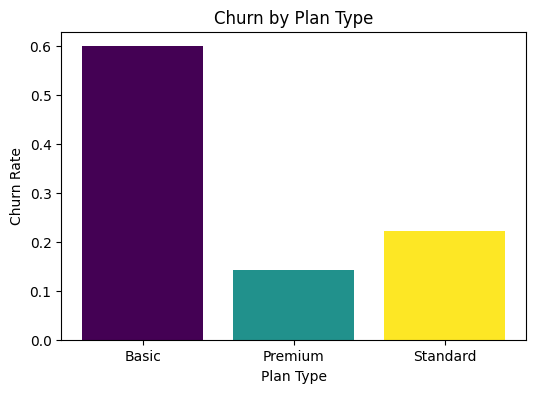

In [66]:
# churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(6,4))
colors = plt.cm.viridis(np.linspace(0, 1, len(churn_plan)))
plt.bar(churn_plan.index, churn_plan.values, color=colors)



plt.title('Churn by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')
plt.show()

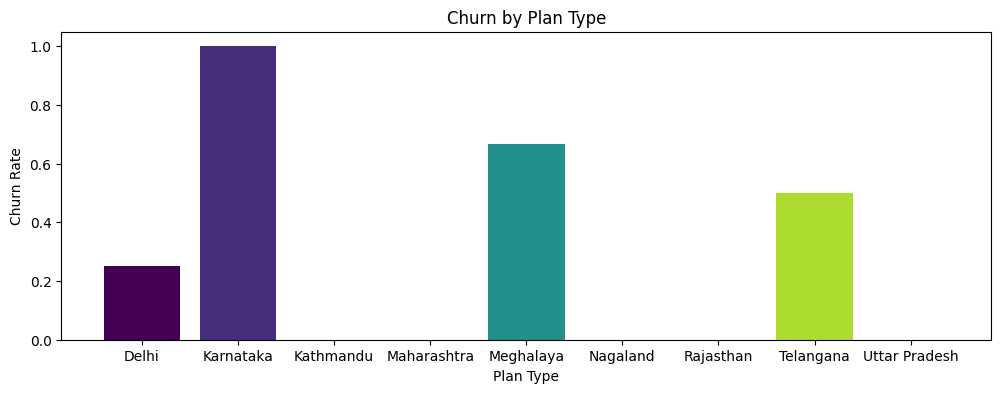

In [67]:
# churn by states
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

plt.figure(figsize=(12,4))
colors = plt.cm.viridis(np.linspace(0, 1, len(churn_plan)))
plt.bar(churn_plan.index, churn_plan.values, color=colors)



plt.title('Churn by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')
plt.show()


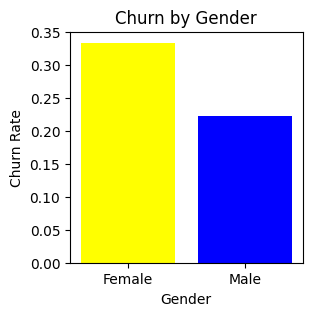

In [68]:
# churn by gender
churn_plan = df_visual.groupby('gender')['churn_flag'].mean()

plt.figure(figsize=(3,3))

plt.bar(churn_plan.index, churn_plan.values, color=['yellow', 'blue'])



plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.show()

5. Visualization using Seaborn

In [69]:
#encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [86]:
#df_encoded =
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [ ]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()


In [72]:
df_encoded.head()

,plan_type,contract_type,churn_flag,churn_risk,escalations
0,2,0,0,1,0
1,1,0,1,0,1
2,0,1,0,1,0
3,1,0,0,1,0
4,2,1,1,0,1


In [88]:
import warnings
warnings.filterwarnings("ignore")

In [90]:
#incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag','churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

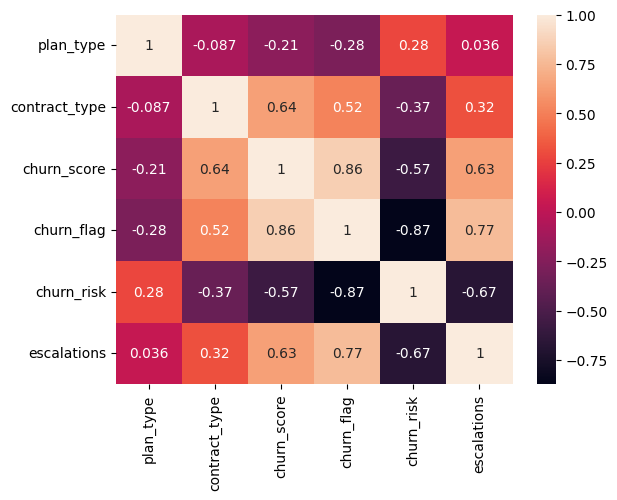

In [92]:
#Heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

In [93]:
#correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag','churn_risk', 'escalations']]

order_mapping = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk' : ['low', 'med', 'high']
}

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order,ordered=True).codes


In [94]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag','churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [95]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

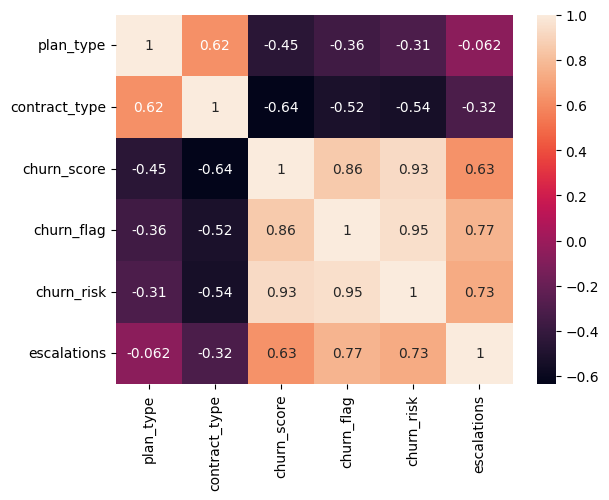

In [96]:
#Heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

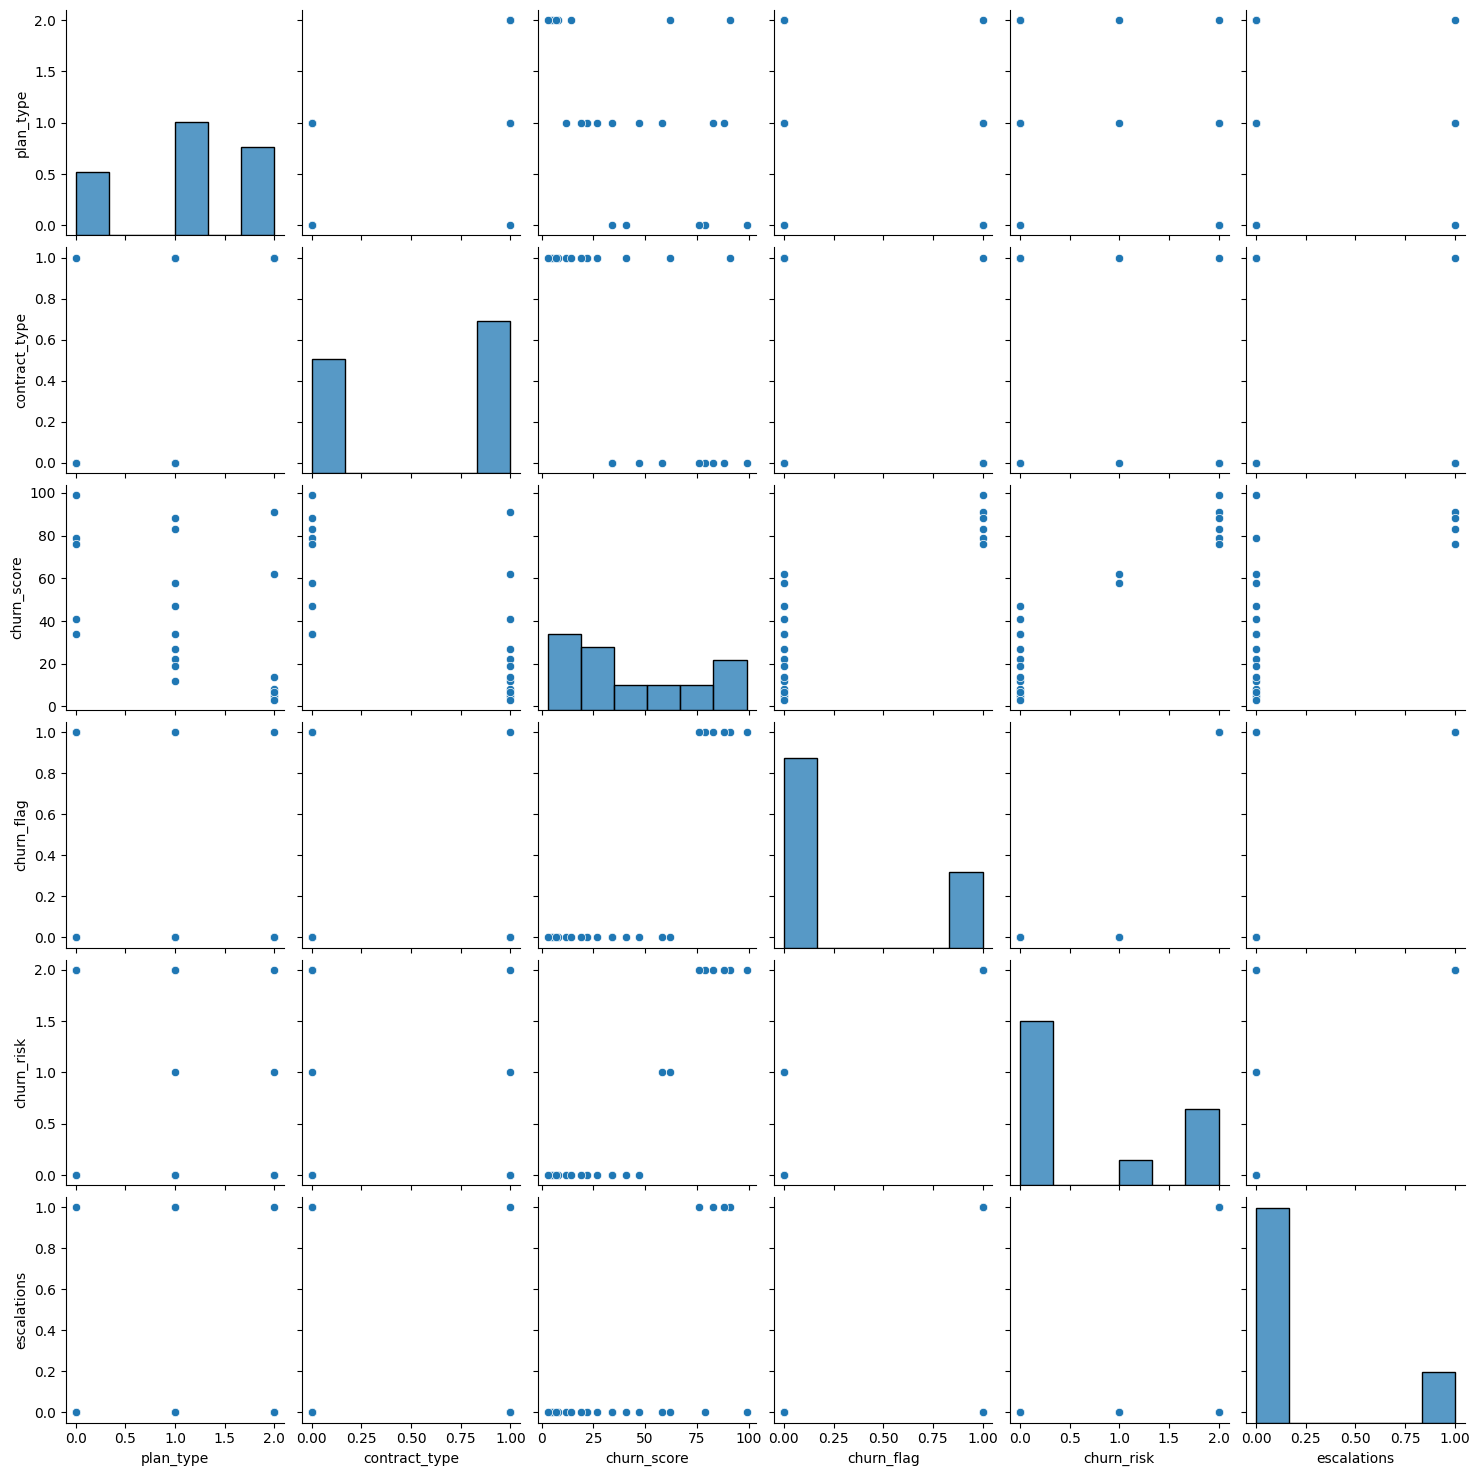

In [97]:
#pairplot - relationship in a dataset
sns.pairplot(df_encoded)

In [98]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

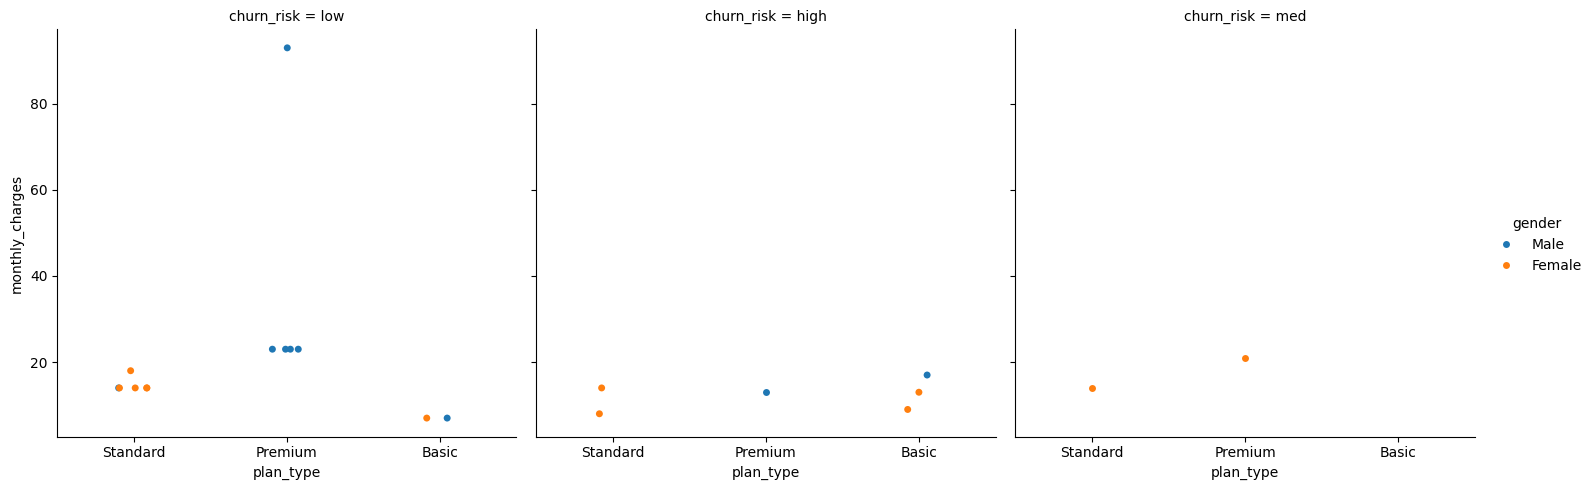

In [99]:
#catplt/facegrid plot - multi-dim comparison
sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [ ]:
#pivot table

In [101]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [103]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc={
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag': 'mean'
     }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


**INSIGHTS**

Insights

*   Churn Rate: 28.6% | Retention Rate: 71.4%

*   Most of the churn is from basic subscription plan - nothing to worry in terms of major revenue impact.


*   Most of the churn happened in the month of sep 2024 and, most affected is Karnataka.

*   Average Tenure(Days): 1,547 | ARPU is Rs 18.8.



*   Total Revenue = 395

*   Revenue loss due to churn = 74 | CLTV lost = 2,047.

*   % Revenue loss = 18%


Actionable Items

*   Check what happened in Karnataka - was there any increase in price, user complaints, tech issues, etc

* Did we increased subs price for Basic plan or recently made any changes - specially in sep month?

* Check what competitior is doing - bcoz one user has moved to competitor

* Focus on customers with 'High' & 'Med' churn risk, check their LTV (to make priority list), complaint request, reach out to them through emails, sms, calls and fix their isssue.




